<a href="https://colab.research.google.com/github/kestrel677/Supervised-Machine-learning-/blob/main/KNN_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [57]:
df = pd.read_csv("/content/Fraud Detection Dataset.csv")
df


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0


In [58]:
df.shape

(51000, 12)

In [59]:
df= df.drop(columns=['Transaction_ID', 'User_ID'])

In [60]:
df.dtypes

,0
Transaction_Amount,float64
Transaction_Type,object
Time_of_Transaction,float64
Device_Used,object
Location,object
Previous_Fraudulent_Transactions,int64
Account_Age,int64
Number_of_Transactions_Last_24H,int64
Payment_Method,object
Fraudulent,int64


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                48480 non-null  float64
 1   Transaction_Type                  51000 non-null  object 
 2   Time_of_Transaction               48448 non-null  float64
 3   Device_Used                       48527 non-null  object 
 4   Location                          48453 non-null  object 
 5   Previous_Fraudulent_Transactions  51000 non-null  int64  
 6   Account_Age                       51000 non-null  int64  
 7   Number_of_Transactions_Last_24H   51000 non-null  int64  
 8   Payment_Method                    48531 non-null  object 
 9   Fraudulent                        51000 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 3.9+ MB


In [62]:
df.describe()

,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [63]:
df.isnull().sum()

,0
Transaction_Amount,2520
Transaction_Type,0
Time_of_Transaction,2552
Device_Used,2473
Location,2547
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0
Payment_Method,2469
Fraudulent,0


In [64]:
df.duplicated().sum()

np.int64(881)

In [65]:
num_cols_to_impute = ['Transaction_Amount', 'Time_of_Transaction']
cat_cols_to_impute = ['Device_Used', 'Location', 'Payment_Method']

df[num_cols_to_impute] = df[num_cols_to_impute].fillna(df[num_cols_to_impute].median())
for col in cat_cols_to_impute:
    df[col] = df[col].fillna(df[col].mode()[0])

In [66]:
df.isnull().sum()

,0
Transaction_Amount,0
Transaction_Type,0
Time_of_Transaction,0
Device_Used,0
Location,0
Previous_Fraudulent_Transactions,0
Account_Age,0
Number_of_Transactions_Last_24H,0
Payment_Method,0
Fraudulent,0


In [67]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Fraudulent')
print(num_cols)

Index(['Transaction_Amount', 'Time_of_Transaction',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H'],
      dtype='object')


In [68]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

                             Column  Outlier_Count
0                Transaction_Amount            508
1               Time_of_Transaction              0
2  Previous_Fraudulent_Transactions              0
3                       Account_Age              0
4   Number_of_Transactions_Last_24H              0


In [69]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

                             Column  Outlier_Count  Percentage
0                Transaction_Amount            508    0.996078
1               Time_of_Transaction              0    0.000000
2  Previous_Fraudulent_Transactions              0    0.000000
3                       Account_Age              0    0.000000
4   Number_of_Transactions_Last_24H              0    0.000000


Step 5: Outliers Visualization

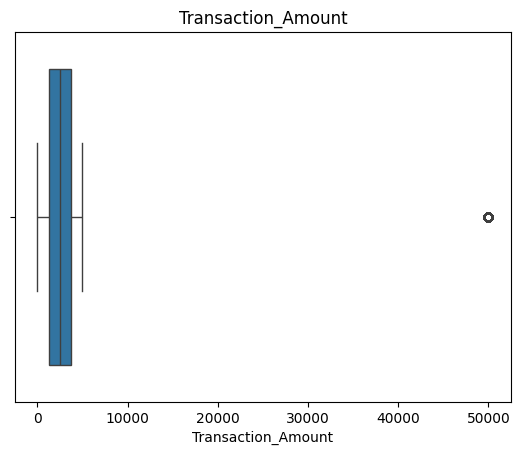

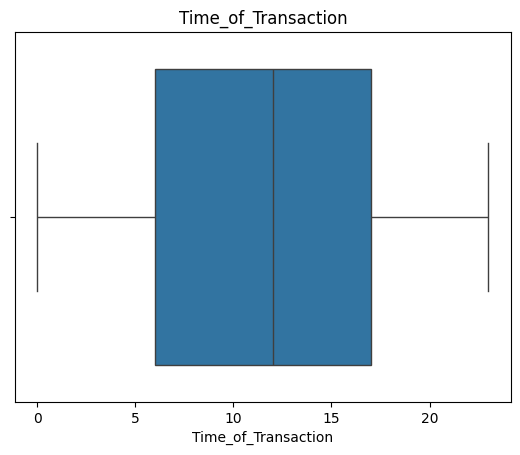

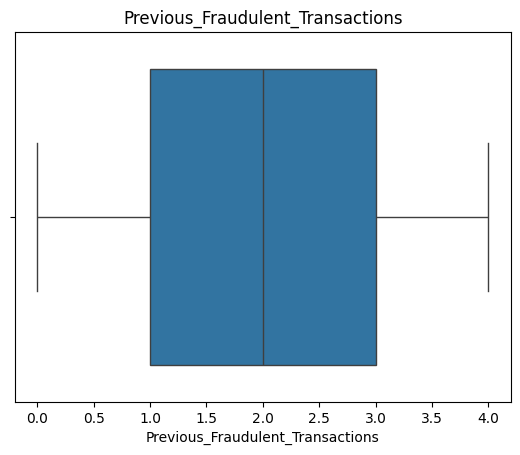

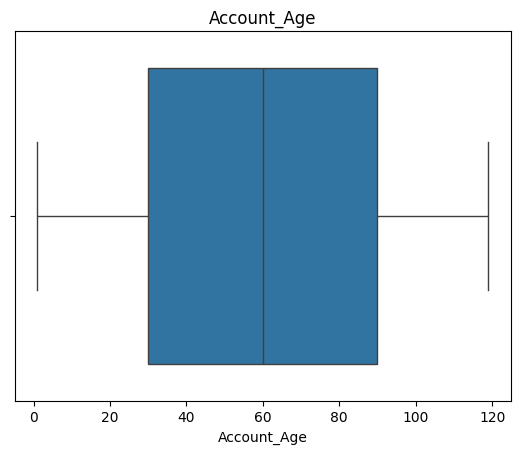

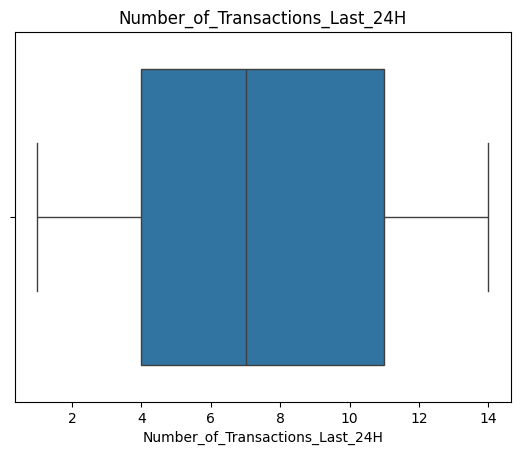

In [70]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [71]:
cols_to_cap = ['Transaction_Amount']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

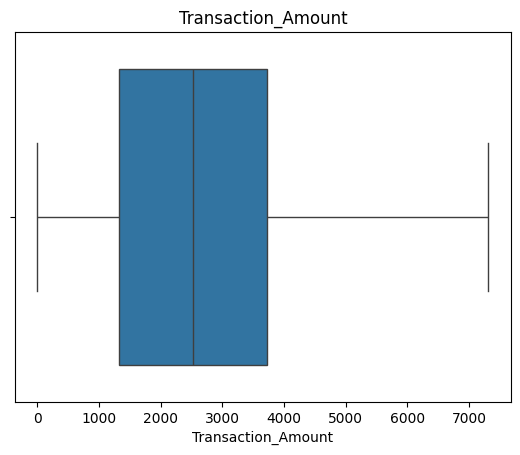

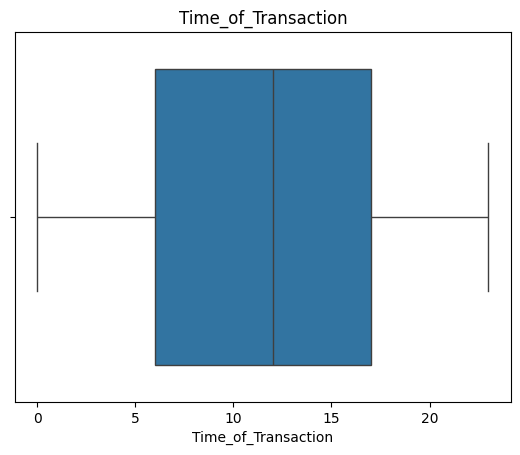

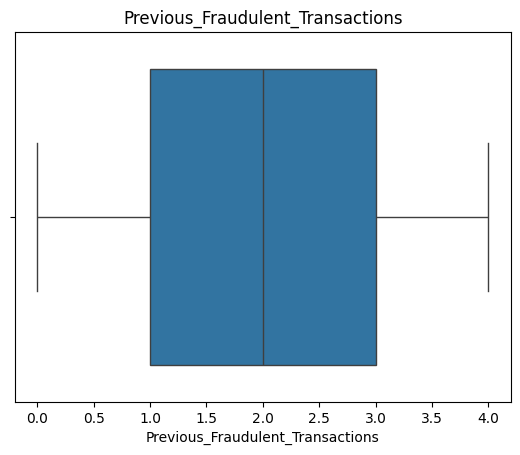

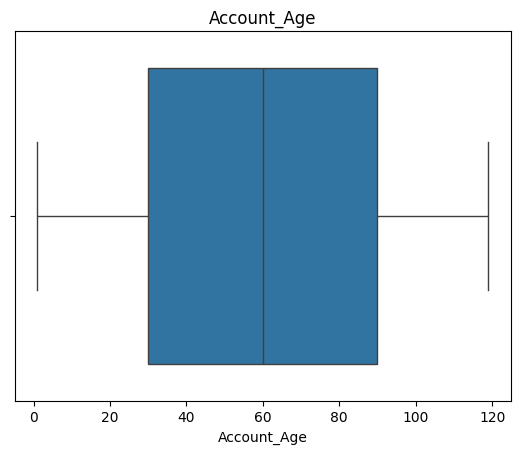

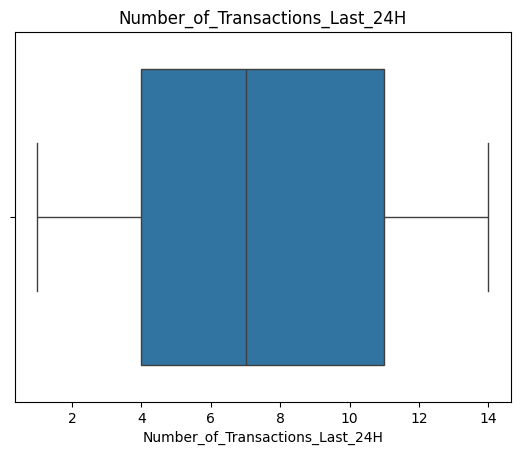

In [72]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df.drop('Fraudulent', axis=1)
y = df['Fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols]

In [74]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=8)

In [75]:
y_pred = knn.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9497058823529412

In [77]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9688
           1       0.00      0.00      0.00       512

    accuracy                           0.95     10200
   macro avg       0.47      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



In [78]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[9687    1]
 [ 512    0]]


In [79]:
y_prob = knn.predict_proba(X_test)[:, 1]

In [80]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [81]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.5182923018489368


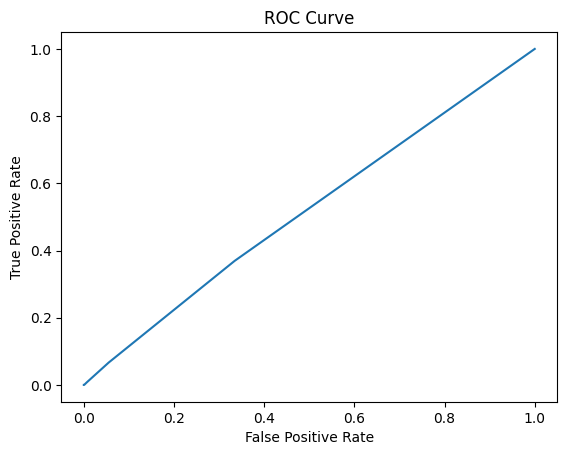

In [82]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()